<a target="_blank" href="https://colab.research.google.com/github/MScEcologyAndDataScienceUCL/BIOS0032_AI4Environment/blob/main/DNA/practical.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# DNA practical

In this notebook you will get hands-on experience in the analysis of environmental DNA samples.
We will use data from a 2025 study by Alejandro Maeda Obregón et al. of a freshwater system in Mexico City.

Here's what we will cover:

- What sequencing data looks like and how to read it
- Perform quality control on reads to remove noise.
- Assign taxonomy to the obtained sequences.
- Explore the outputs to gain insights into the communities found in the study area.

# Setup

Before we start, make sure you are running an R runtime.
You can check by looking at the bottom right corner, which should display "R".
To change the runtime, click "Change runtime type" in the "Runtime" menu (top menu bar).

Next, please run the following setup code to download the data and install the missing packages.

In [1]:
system(
  "curl -LsSf https://github.com/MScEcologyAndDataScienceUCL/BIOS0032_AI4Environment/raw/refs/heads/main/DNA/setup.sh | sh",
  intern = TRUE
)

[1] "Archive:  r_dada_dependencies.zip"                                                                                                           
    [2] "   creating: /usr/local/lib/R/site-library/sp/"                                                                                              
    [3] "   creating: /usr/local/lib/R/site-library/sp/html/"                                                                                         
    [4] "  inflating: /usr/local/lib/R/site-library/sp/html/00Index.html  "                                                                           
    [5] "  inflating: /usr/local/lib/R/site-library/sp/html/R.css  "                                                                                  
    [6] "   creating: /usr/local/lib/R/site-library/sp/external/"                                                                                     
    [7] "  inflating: /usr/local/lib/R/site-library/sp/external/simple.ag  "                                                                          
    [8] "  inflating: /usr/local/lib/R/site-library/sp/external/test.ag  "                                                                            
    [9] "  inflating: /usr/local/lib/R/site-library/sp/external/seamap105_mod.csv  "                                                                  
   [10] "  inflating: /usr/local/lib/R/site-library/sp/CITATION  "                                                                                    
   [11] "  inflating: /usr/local/lib/R/site-library/sp/INDEX  "                                                                                       
   [12] "   creating: /usr/local/lib/R/site-library/sp/demo/"                                                                                         
   [13] "  inflating: /usr/local/lib/R/site-library/sp/demo/gallery.R  "                                                                              
   [14] "  inflating: /usr/local/lib/R/site-library/sp/demo/meuse.R  "                                                                                
   [15] "  inflating: /usr/local/lib/R/site-library/sp/demo/depend.R  "                                                                               
   [16] "  inflating: /usr/local/lib/R/site-library/sp/demo/polar.R  "                                                                                
   [17] "  inflating: /usr/local/lib/R/site-library/sp/demo/fib.R  "                                                                                  
   [18] "  inflating: /usr/local/lib/R/site-library/sp/demo/mp.R  "                                                                                   
   [19] "   creating: /usr/local/lib/R/site-library/sp/Meta/"                                                                                         
   [20] " extracting: /usr/local/lib/R/site-library/sp/Meta/nsInfo.rds  "                                                                             
   [21] " extracting: /usr/local/lib/R/site-library/sp/Meta/hsearch.rds  "                                                                            
   [22] " extracting: /usr/local/lib/R/site-library/sp/Meta/demo.rds  "                                                                               
   [23] " extracting: /usr/local/lib/R/site-library/sp/Meta/package.rds  "                                                                            
   [24] " extracting: /usr/local/lib/R/site-library/sp/Meta/vignette.rds  "                                                                           
   [25] " extracting: /usr/local/lib/R/site-library/sp/Meta/features.rds  "                                                                           
   [26] " extracting: /usr/local/lib/R/site-library/sp/Meta/links.rds  "                                                                              
   [27] " extracting: /usr/local/lib/R/site-library/sp/Meta/Rd.rds  "         

If successful, you should be able to import the libraries below.

In [2]:
library(dplyr)
library(dada2)
library(ShortRead)
library(Biostrings)
library(lulu)
library(phyloseq)
library(ape)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Rcpp

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:dplyr’:

    combine


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, m

Finally, the data is in the `data` folder.

In [3]:
data_dir <- "data"

And let's load some utility functions to help us with the analysis.

In [4]:
source("utils.R")

# Xochimilco

The study was conducted in Lake Xochimilco, a wetland and World Heritage Site within Mexico City.
With growing urbanisation, the lake has now been engulfed by the city and has become a varied aquascape of narrow canals, six small lakes, and two flood plains.

![Landscape of Xochimilco wetlands](https://upload.wikimedia.org/wikipedia/commons/thumb/f/f2/Paisaje_del_canal_y_chinampas_en_Xochimilco.JPG/1280px-Paisaje_del_canal_y_chinampas_en_Xochimilco.JPG)

It has a long history of use for food production, with some unique pre-Hispanic agricultural practices still in place. It is also increasingly used for recreation and is subject to growing contamination from the surrounding urban landscape.

![Picture of Trajineras, a popular boat ride in Xochimilco](https://upload.wikimedia.org/wikipedia/commons/5/5b/Trajineras_and_canals_of_Xochimilco_04.jpg)

This lake historically contained at least 20 species of fish and 3 amphibians, with two being of important cultural significance, *Tlaloc's frog* (*Lithobates tlaloci*) and the famous Axolotl (*Ambystoma mexicanum*).
Yet the native biodiversity has been declining, also due to the introduction of non-native species, and the degradation of the wetland habitat.

![Picture of Axolotl](https://upload.wikimedia.org/wikipedia/commons/1/15/Axolotl_ambystoma_mexicanum_anfibio_ASAG.jpg)

The main focus of Alejandro's work was to use eDNA methods to assess the extent of colonisation by invasive species in the system, identify conditions where rare but important native species occur, and understand how environmental stressors affect native versus non-native species.

For this, he collected water samples across 43 wild sites in the lake, then filtered the water to collect DNA.
At each site, a range of water and environmental characteristics was measured.
Here is the metadata collected at each site.

In [5]:
metadata_dir <- file.path(data_dir, "metadata")

site_df <- read.csv(file.path(metadata_dir, "LX_Site_Data.csv"))

site_df

SITENUMBER,TYPE,NAME,SITE_TYPE,LATITUDE,LONGITUDE,pH,Water_temperature.ºC.,EC.mS.,TDS.ppt.,Dissolved_oxygen.mg.L.,NITRATE,NITRITE,AMMONIA,PHOSPHATE,SULPHATE,SULPHUR,CHLORINE
<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,Wild site,Canal Japón I,Large Canal,19.28318,-99.07012,8.86,16.6,0.88,0.44,16.7,3.21,0.22,0.00,0.03,149,0.00,0.24
2,Wild site,Canal Japón II,Large Canal,19.28117,-99.07778,8.84,16.3,0.85,0.44,16.7,7.00,0.42,0.00,1.53,75,0.07,0.21
3,Wild site,Canal Paso del Águila,Large Canal,19.27378,-99.08597,8.40,17.7,0.87,0.45,20.0,8.80,0.68,0.00,1.76,110,0.03,0.47
4,Wild site,Laguna de Teshuilo,Lagoon,19.27101,-99.08768,8.65,18.3,0.95,0.44,20.0,12.60,0.57,0.00,1.67,96,0.04,0.14
5,Wild site,Canal de Teshuilo,Large Canal,19.26823,-99.08878,8.57,17.7,1.10,0.53,20.0,8.20,0.29,1.00,0.19,17,0.02,2.10
6,Wild site,Canal Apatlaco,Large Canal,19.26436,-99.08957,8.30,17.7,1.07,0.56,16.6,5.80,0.39,0.00,0.05,88,0.03,0.27
7,Wild site,Canal El Bordo I,Large Canal,19.28341,-99.08023,8.31,18.5,0.95,0.49,20.0,8.50,0.09,0.34,0.03,133,0.01,0.28
8,Refuge,Felipe Barerra’s refuge,Refuge,19.27319,-99.09401,9.22,18.5,1.11,0.55,15.4,1.25,0.00,0.00,0.63,113,0.00,0.07
9,Refuge,Olintalli refuge,Refuge,19.27821,-99.09422,8.00,16.2,1.04,0.53,4.5,0.12,0.09,0.81,22.40,92,0.05,0.33


Let's look at the map.

Loading required namespace: raster

Zoom: 14

Fetching 12 missing tiles

...complete!

Warning message in geom2trace.default(dots[[1L]][[1L]], dots[[2L]][[1L]], dots[[3L]][[1L]]):
“geom_GeomMapTile() has yet to be implemented in plotly.
  If you'd like to see this geom implemented,
  Please open an issue with your example code at
  https://github.com/ropensci/plotly/issues”


  |======================================================================| 100%

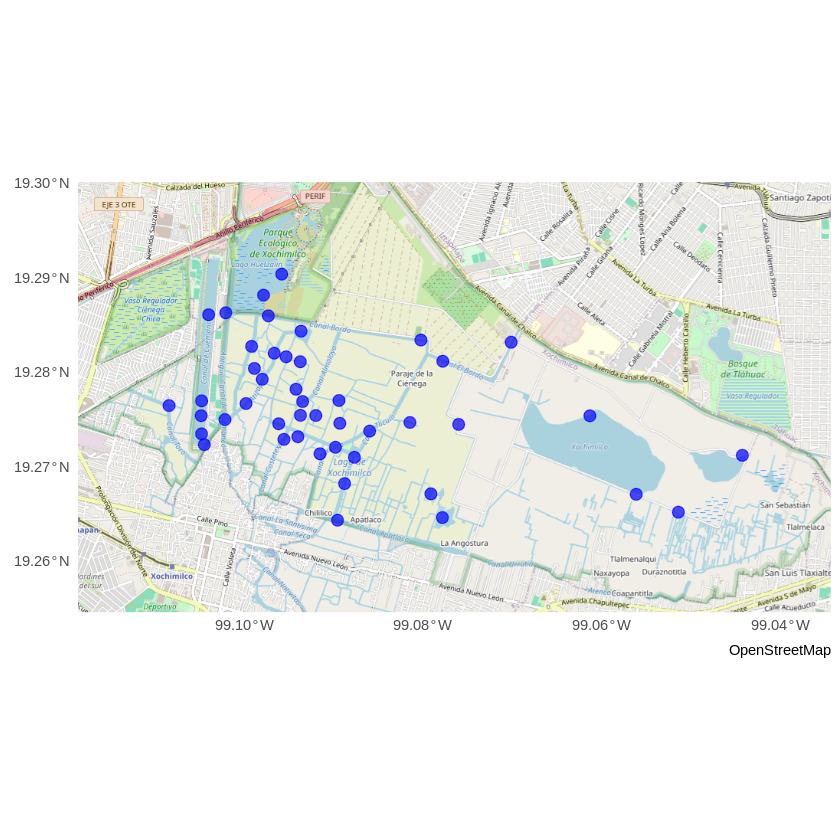

In [6]:
site_sf <- sf::st_as_sf(
  site_df,
  coords = c("LONGITUDE", "LATITUDE"),
  crs = 4326
)

buffered_bbox_sf <- site_sf |>
  sf::st_bbox() |>
  sf::st_as_sfc() |>
  sf::st_buffer(dist = 1000)

ggplot2::ggplot() +
  ggspatial::annotation_map_tile(
    data = buffered_bbox_sf,
    type = "osm",
    zoom = 13
  ) +
  ggspatial::layer_spatial(site_sf, size = 3, color = "blue", alpha = 0.7) +
  ggplot2::theme_minimal() +
  ggspatial::coord_sf(
    xlim = sf::st_bbox(buffered_bbox_sf)[c(1, 3)],
    ylim = sf::st_bbox(buffered_bbox_sf)[c(2, 4)],
    expand = FALSE
  ) +
  ggplot2::labs(caption = "OpenStreetMap")

Some areas are further away from dense urban zones and are more pristine.

What do you expect?
- If the axolotls are there, where would we find them?
- How do you think the number of different species is distributed?

# Data

Now we will work with only a subset of the data to make the practical easier to follow and faster to run.
Genetic pipelines can be slow to run.
However the samples we will be using come from the same study site.

An important part of DNA sequencing is choosing the right primers.
Primers attach to particular regions of the genome and determine what portions of the genome are amplified and sequenced.
Primers are similar to MegaDetector in the sense that they help identify sequences of interest while filtering out most of the rest.
So it is important to choose primers that are specific to the target sequences.

In this case, Alejandro designed a primer set specific to the mitochondrial 16S rRNA gene.
He focused on a hypervariable region of around 250 base pairs (bp), which had been previously described as suitable for 16S rRNA barcoding.
"Hypervariable" means we expect to see differences in this region between species.
By checking a reference dataset, primers can be selected to bind mostly to the target group, which here was amphibians.

In [7]:
primers <- c(
  forward = "ACGAGAAGACCCTATGGARCT",
  reverse = "TCCTGATCCAACATCGAGGTC"
)

The water samples were sequenced using the Illumina MiSeq platform.
Broadly speaking, this platform amplifies what binds to the primers and then reads those sequences in parallel.
The results are processed and saved in a file called a FASTQ file.
Let's have a look at the files we collected.

In [8]:
# Folder with raw sequence files
raw_dir <- file.path(data_dir, "raw")

# get file list
files <- list.files(raw_dir, pattern = "*.fastq.gz")

files

[1] "21_S21_L001_R1_001.fastq.gz" "21_S21_L001_R2_001.fastq.gz"
 [3] "22_S22_L001_R1_001.fastq.gz" "22_S22_L001_R2_001.fastq.gz"
 [5] "23_S23_L001_R1_001.fastq.gz" "23_S23_L001_R2_001.fastq.gz"
 [7] "24_S24_L001_R1_001.fastq.gz" "24_S24_L001_R2_001.fastq.gz"
 [9] "25_S25_L001_R1_001.fastq.gz" "25_S25_L001_R2_001.fastq.gz"
[11] "26_S26_L001_R1_001.fastq.gz" "26_S26_L001_R2_001.fastq.gz"
[13] "27_S27_L001_R1_001.fastq.gz" "27_S27_L001_R2_001.fastq.gz"
[15] "28_S28_L001_R1_001.fastq.gz" "28_S28_L001_R2_001.fastq.gz"
[17] "29_S29_L001_R1_001.fastq.gz" "29_S29_L001_R2_001.fastq.gz"
[19] "30_S30_L001_R1_001.fastq.gz" "30_S30_L001_R2_001.fastq.gz"
[21] "31_S31_L001_R1_001.fastq.gz" "31_S31_L001_R2_001.fastq.gz"
[23] "32_S32_L001_R1_001.fastq.gz" "32_S32_L001_R2_001.fastq.gz"
[25] "33_S33_L001_R1_001.fastq.gz" "33_S33_L001_R2_001.fastq.gz"
[27] "34_S34_L001_R1_001.fastq.gz" "34_S34_L001_R2_001.fastq.gz"
[29] "35_S35_L001_R1_001.fastq.gz" "35_S35_L001_R2_001.fastq.gz"
[31] "36_S36_L001_R1_001.fastq.gz" "36_S36_L001_R2_001.fastq.gz"
[33] "37_S37_L001_R1_001.fastq.gz" "37_S37_L001_R2_001.fastq.gz"
[35] "38_S38_L001_R1_001.fastq.gz" "38_S38_L001_R2_001.fastq.gz"
[37] "39_S39_L001_R1_001.fastq.gz" "39_S39_L001_R2_001.fastq.gz"
[39] "40_S40_L001_R1_001.fastq.gz" "40_S40_L001_R2_001.fastq.gz"

Each sample has two files, one for the forward and one for the reverse.
Each sample has an ID.
Let's create a table with the file information for each sample.

In [9]:
# Create table with file information
file_df_long <- dplyr::tibble(file = files) |>
  dplyr::mutate(
    sample_id = as.integer(sub("_.*", "", files)),
    direction = dplyr::case_when(
      stringr::str_detect(file, "_1\\.|_R1_") ~ "forward",
      stringr::str_detect(file, "_2\\.|_R2_") ~ "reverse",
      TRUE ~ "unknown"
    )
  ) |>
  dplyr::arrange(sample_id)

file_df_wide <- file_df_long |>
  tidyr::pivot_wider(
    id_cols = c(sample_id),
    names_from = direction,
    values_from = file,
    names_glue = "{direction}"
  )

file_df_wide

sample_id,forward,reverse
<int>,<chr>,<chr>
21,21_S21_L001_R1_001.fastq.gz,21_S21_L001_R2_001.fastq.gz
22,22_S22_L001_R1_001.fastq.gz,22_S22_L001_R2_001.fastq.gz
23,23_S23_L001_R1_001.fastq.gz,23_S23_L001_R2_001.fastq.gz
24,24_S24_L001_R1_001.fastq.gz,24_S24_L001_R2_001.fastq.gz
25,25_S25_L001_R1_001.fastq.gz,25_S25_L001_R2_001.fastq.gz
26,26_S26_L001_R1_001.fastq.gz,26_S26_L001_R2_001.fastq.gz
27,27_S27_L001_R1_001.fastq.gz,27_S27_L001_R2_001.fastq.gz
28,28_S28_L001_R1_001.fastq.gz,28_S28_L001_R2_001.fastq.gz
29,29_S29_L001_R1_001.fastq.gz,29_S29_L001_R2_001.fastq.gz


# Understand the file format: `fastq`

The `fastq` format is a standard format for storing sequence data.
Many sequencing platforms produce files in this format, and it serves as the de facto
standard for DNA sequencing.

The data is stored as text, and you can see that it comes in blocks of 4 lines.
Each block represents a "read" of a DNA sequence.

Let's look at the first 4 lines of the sample file:

In [10]:
sample_file <- file.path(raw_dir, file_df_long$file[4])

readLines(sample_file, n = 4)

[1] "@M00969:59:000000000-DF8RT:1:1101:15776:2088 2:N:0:22"                                                                                                                                                                                                      
[2] "TCCTGTTCCAACATCGAGGTCGTAAACCCCCTCGTCGATATGGACTCTGGGAGAGGATTGCGCTGTTATCCCTAGGGTAACTTGGTTCGTTGATCGGCTATGTGTTAGCCGGATCATATTTGGTCAGATGTTCTGTGGCTTAGAGATGTCTCTCTTGGTTTTAGGAGGTTTTCCCAGTCCACCTGGAGGCTTTTCTTTCCTCCGTGGTCGCCCCAACCGAAGGTAAAATCTCATGGTCCACAAGGTTTTTT"
[3] "+"                                                                                                                                                                                                                                                          
[4] "AA1>11B3333@AFEEBE1EAAFC00BFEE?E0AGAA/A/E2EDAG0G110CA/E/0GGCG/>E@GGGHFFEHHBCEGFFGHHGBHHF?FH0CGEF/EFEHFHFHHFFBE??/CBFHGHHHHGHGECGG1GGGH1GG0FGGC1D11F1GHHGHHHEG1GHHGG0<10<CGGGFHGFEGGCDCGH/.:..:GFHHHHGHHFFFGBFE?EGG@CF@?CCC@@<@BFFFFFFFFFFF/9FFFFFFEF-FFFFF-"

The first line contains metadata about that sequence.
Here we can see `@M00969:59:000000000-DF8RT:1:1101:15776:2088 2:N:0:22`, which
contains the sample ID and detailed information about where this sequence was found within the run.
But no need to worry about that for now.

The second line contains the actual sequence of bases for that read.
You may find occasional "N" in the sequence, which means that the machine was
not able to identify that base for any number of reasons.

Then there is a line with a "+" character.
And finally the next line contains the quality scores for that read.
The quality scores, or "phred scores", quantify sequence quality.
They estimate the probability that each base call is correct.
The scores usually range from 10 to 40, and they are encoded as characters
so that one character represents one score and thus the number of characters in
the quality scores line is equal to the length of the sequence.
A character "!" is the lowest score, and "~" is the highest.
Thankfully the software does the mapping for us.

We can plot the quality profile of a sample, including both forward and reverse reads.

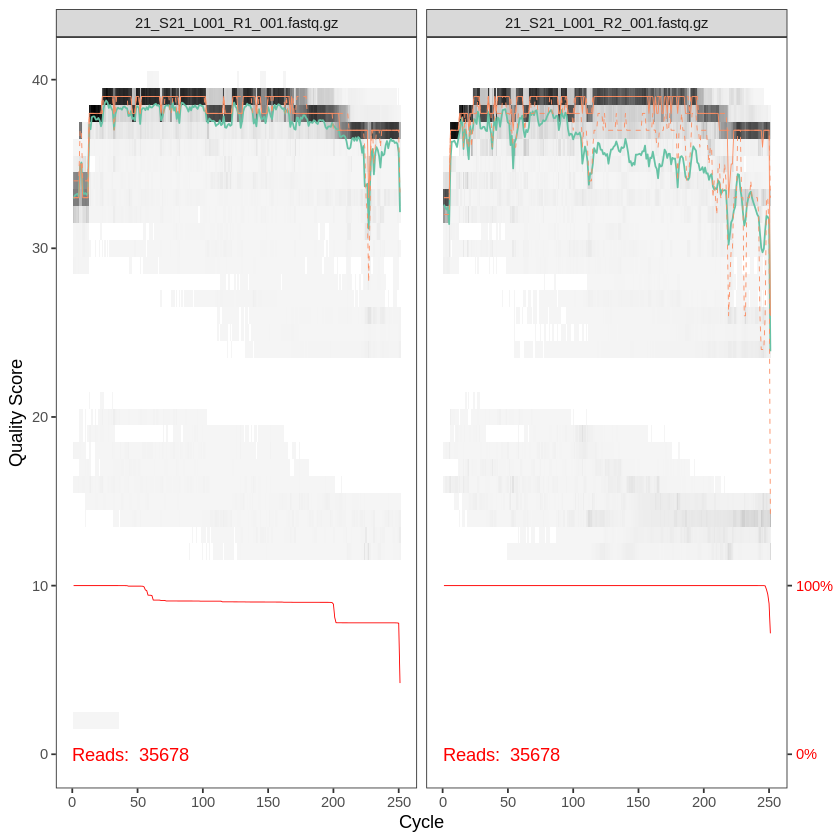

In [11]:
# Read first sample (2 files, forward and reverse)
dada2::plotQualityProfile(file.path(raw_dir, file_df_long$file[1:2]))

There's a lot to unpack here, but here are some key points:

- The x axis is the position in the read, and the y axis is the quality score.
- The gray to black background heatmap shows the distribution of quality scores for each position in the read, across all reads in the file.
- The green line shows the median quality score for each position in the read.
- In general, we hope to see quality scores near 40; especially, the black regions should be high.
- The red line below shows read length information. For any given position, it shows the percentage of reads with length at least that value.

We can also quickly check how many reads we have per sample.

In [12]:
counts_raw <- ShortRead::countFastq(raw_dir) |>
  dplyr::select(records, nucleotides)

counts_raw

,records,nucleotides
,<dbl>,<dbl>
21_S21_L001_R1_001.fastq.gz,35678,8058058
21_S21_L001_R2_001.fastq.gz,35678,8938587
22_S22_L001_R1_001.fastq.gz,26207,6298193
22_S22_L001_R2_001.fastq.gz,26207,6572807
23_S23_L001_R1_001.fastq.gz,2290,458156
23_S23_L001_R2_001.fastq.gz,2290,571955
24_S24_L001_R1_001.fastq.gz,13907,3218326
24_S24_L001_R2_001.fastq.gz,13907,3488814
25_S25_L001_R1_001.fastq.gz,9476,1847081


# Quality control

DNA sequencing involves a lot of noise and there are multiple places where something can go wrong.

- Contamination of the sample.
- A DNA strand was unintentionally read, even though it was not targeted by our primers.
- A base pair was read incorrectly.
- Etc.

Rather than taking the sequences at face value, i.e. all reads are true, a first important part of the bioinformatics pipeline is quality control.
A lot of effort has gone into developing methods to identify and remove noise from sequencing data.
The goal is to ensure that sequences retained by the pipeline represent true biological entities.
In DNA data, false positives are especially problematic, so quality control is usually tuned for higher precision, even if recall drops slightly.

Quality control involves both automated and manual steps.
Automated methods are evolving and often rely on machine learning and statistical methods to identify noise.
Here we will use commonly used tools: DADA2 and cutadapt.
Optionally we can also use the `lulu` package to remove other sources of noise.

## Removal of ambiguous bases

Sequencers can fail to read some base pairs in the sequence, for any number of reasons.
These are called ambiguous bases, and are usually represented by the letter `N`.
Downstream analyses compare sequences, so an ambiguous base can disrupt comparisons and add noise.
Reads with ambiguous bases are unreliable, hence we pre-filter them out.

Let's create a folder to store the pre-filtered files.

In [13]:
pre_filter_dir <- file.path(data_dir, "pre_filter")

if (!dir.exists(pre_filter_dir)) {
  dir.create(pre_filter_dir)
}

We can filter out these sequences using the `filterAndTrim` function from the `dada2` package.
It removes any read that contains an ambiguous base.


In [14]:
filter_output <- dada2::filterAndTrim(
  fwd = file.path(raw_dir, file_df_wide$forward),
  rev = file.path(raw_dir, file_df_wide$reverse),
  filt = file.path(pre_filter_dir, file_df_wide$forward),
  filt.rev = file.path(pre_filter_dir, file_df_wide$reverse),
  maxN = 0,
  multithread = TRUE
)

And check how many were removed.

In [15]:
counts_pre_filter <- ShortRead::countFastq(pre_filter_dir) |>
  dplyr::select(records, nucleotides)

cbind(
  counts_raw |> dplyr::select(records) |> dplyr::rename(raw = records),
  counts_pre_filter |>
    dplyr::select(records) |>
    dplyr::rename(pre_filter = records)
)

,raw,pre_filter
,<dbl>,<dbl>
21_S21_L001_R1_001.fastq.gz,35678,35661
21_S21_L001_R2_001.fastq.gz,35678,35661
22_S22_L001_R1_001.fastq.gz,26207,26068
22_S22_L001_R2_001.fastq.gz,26207,26068
23_S23_L001_R1_001.fastq.gz,2290,2280
23_S23_L001_R2_001.fastq.gz,2290,2280
24_S24_L001_R1_001.fastq.gz,13907,13768
24_S24_L001_R2_001.fastq.gz,13907,13768
25_S25_L001_R1_001.fastq.gz,9476,9461


## Primer removal

As mentioned earlier, the sequenced fragments are those that bound to our primers in the first place.
The primers are all the same and hence not helpful for analysis.
We need to remove them.

Let's start by counting the number of times each primer is found in each sample.

In [16]:
# Compute all primer counts across all files
counts <- count_primers(
  df = file_df_long,
  primers = primers,
  base_dir = pre_filter_dir
) |>
  dplyr::select(sample_id, direction, forward.total, reverse.total) |>
  print(n = 40)

# A tibble: 40 × 4
   sample_id direction forward.total reverse.total
       <int> <chr>             <int>         <int>
 1        21 forward           33031          7476
 2        21 reverse            7354         33395
 3        22 forward           24146          1621
 4        22 reverse            1629         24575
 5        23 forward            2041           984
 6        23 reverse            2005          2157
 7        24 forward           12741          1242
 8        24 reverse            1258         13051
 9        25 forward            8870          8685
10        25 reverse            8545          8934
11        26 forward           43045         34663
12        26 reverse           34346         43766
13        27 forward           13134         13129
14        27 reverse           12881         13390
15        28 forward            3877          3893
16        28 reverse            3786          3941
17        29 forward           32395         25212
18        29

Both primers are found in all samples.
To remove them, we will use `cutadapt`.
This is a command line tool that can be used to trim the reads.
It looks for primers in the edges of the reads and removes them.
But it can leave primer hits in the middle of the read.

Any sample that does not have a primer hit will be discarded too.
This is because it may be a sequence that was randomly amplified and sequenced, but is not biologically relevant.

Let's create a folder to store the resulting files.

In [17]:
cutadapt_dir <- file.path(data_dir, "cutadapt")

if (!dir.exists(cutadapt_dir)) {
  dir.create(cutadapt_dir)
}

And let's run the function. This utility function calls `cutadapt` under the hood, but no need to worry about that now.
The important thing is to note that we are specifying a minimum overlap of 10 bases with the primer to be considered a hit and removed.

In [18]:
remove_primers(
  file_df_wide,
  primers,
  base_dir = pre_filter_dir,
  output_dir = cutadapt_dir,
  count = 2,
  minimum_length = 10
)

[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

[[11]]
[1] 0

[[12]]
[1] 0

[[13]]
[1] 0

[[14]]
[1] 0

[[15]]
[1] 0

[[16]]
[1] 0

[[17]]
[1] 0

[[18]]
[1] 0

[[19]]
[1] 0

[[20]]
[1] 0

And just to make sure that the primers are gone, let's count them again.

In [19]:
# Sanity check that primers are gone
counts_after <- count_primers(file_df_long, primers, cutadapt_dir)

counts_after |>
  dplyr::select(sample_id, direction, forward.total, reverse.total) |>
  print(n = 40)

# A tibble: 40 × 4
   sample_id direction forward.total reverse.total
       <int> <chr>             <int>         <int>
 1        21 forward               0             0
 2        21 reverse               0             0
 3        22 forward               0             0
 4        22 reverse               0             0
 5        23 forward               0             0
 6        23 reverse               0             0
 7        24 forward               0             0
 8        24 reverse               0             0
 9        25 forward               0             0
10        25 reverse               0             0
11        26 forward               0             0
12        26 reverse               0             0
13        27 forward               0             0
14        27 reverse               0             0
15        28 forward               0             0
16        28 reverse               0             0
17        29 forward               0             0
18        29

How many reads survived?

In [20]:
counts_cutadapt <- ShortRead::countFastq(cutadapt_dir) |>
  dplyr::select(records, nucleotides)

cbind(
  counts_raw |> dplyr::select(records) |> dplyr::rename(raw = records),
  counts_pre_filter |>
    dplyr::select(records) |>
    dplyr::rename(pre_filter = records),
  counts_cutadapt |>
    dplyr::select(records) |>
    dplyr::rename(cutadapt = records)
)

,raw,pre_filter,cutadapt
,<dbl>,<dbl>,<dbl>
21_S21_L001_R1_001.fastq.gz,35678,35661,34662
21_S21_L001_R2_001.fastq.gz,35678,35661,34662
22_S22_L001_R1_001.fastq.gz,26207,26068,25214
22_S22_L001_R2_001.fastq.gz,26207,26068,25214
23_S23_L001_R1_001.fastq.gz,2290,2280,2007
23_S23_L001_R2_001.fastq.gz,2290,2280,2007
24_S24_L001_R1_001.fastq.gz,13907,13768,13094
24_S24_L001_R2_001.fastq.gz,13907,13768,13094
25_S25_L001_R1_001.fastq.gz,9476,9461,9065


# Phred filtering

So far, we have removed reads with ambiguous bases and trimmed primers, but we still have many low-quality reads.
Low-quality reads mean the machine was not confident about one or more base calls.
A Phred score of 30 roughly means that 1 in 1000 reads are wrong, a Phred score of 20 is 1 in 100 reads, and a Phred score of 10 is 1 in 10.
To avoid working with reads that are likely to contain incorrect bases, we can filter them out.

Most often this means two things:
- Because quality generally decreases with read length, we can trim reads after a chosen position.
- Remove reads with too many expected errors.

So we need to find a suitable truncation length.

Let's look at the quality profiles of the files we have so far:

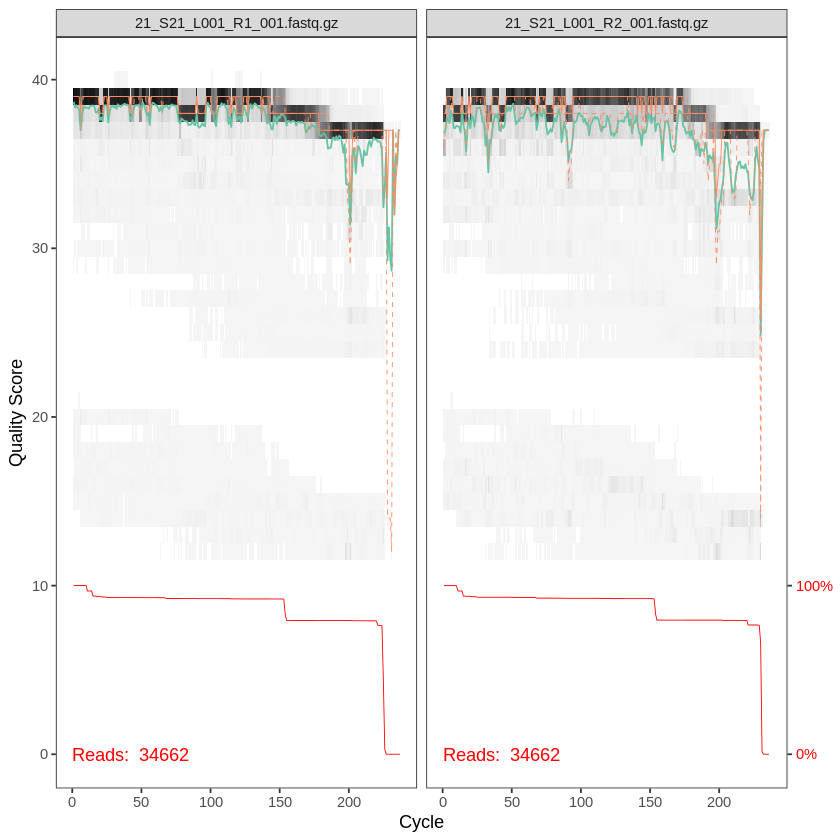

In [21]:
dada2::plotQualityProfile(file.path(cutadapt_dir, file_df_long$file[1:2]))

Notice that the quality seems to degrade around 180 bases approximately.
But there is a significant drop in read length around 140 bases.
Let's look at another example.

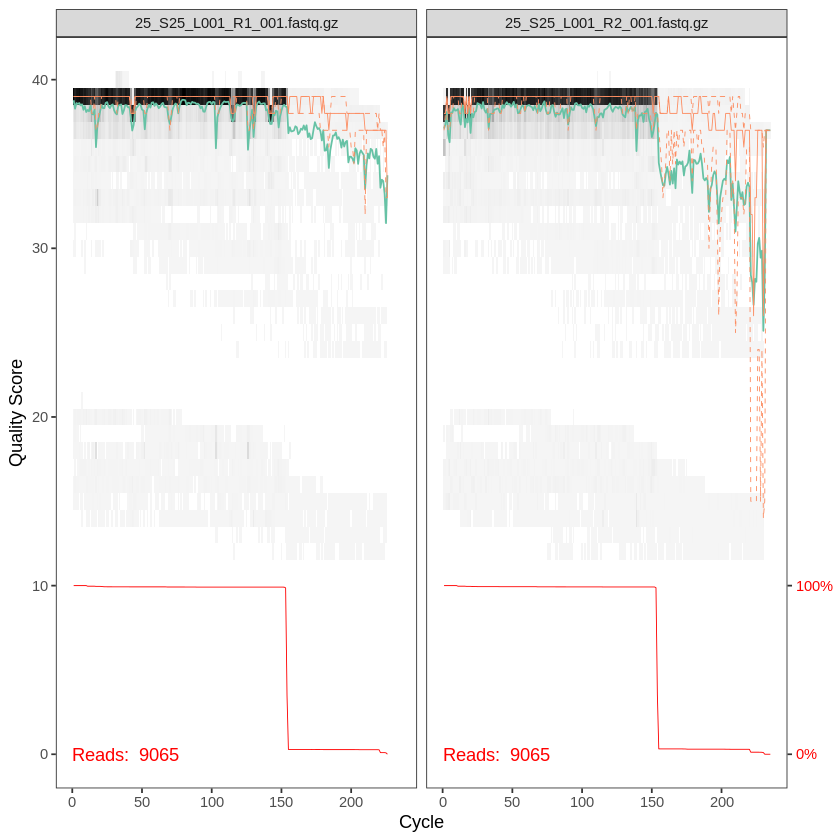

In [22]:
dada2::plotQualityProfile(file.path(cutadapt_dir, file_df_long$file[9:10]))

Here quality drops after 150 bases.

As mentioned earlier, the primers were designed to target a specific region of around 220 bp.
Final sequences are assembled by merging forward and reverse reads, so as long as forward length + reverse length - required overlap is greater than 220 bp, we are fine.
So we can set the truncation length to 150 and still get a good assembly.

With that info we can filter the reads to remove low quality ones.

Let's create a folder to store the resulting files.

In [23]:
filter_dir <- file.path(data_dir, "filter")

if (!dir.exists(filter_dir)) {
  dir.create(filter_dir)
}

And we can use the same `filterAndTrim` function we used before, but with different parameters.
Note that we are specifying the truncation length to be 150. The `maxEE` parameter is set to 2 which means that any read with more than 2 expected errors, even after trimming, is also discarded.

In [24]:
filter_output <- dada2::filterAndTrim(
  fwd = file.path(cutadapt_dir, file_df_wide$forward),
  rev = file.path(cutadapt_dir, file_df_wide$reverse),
  filt = file.path(filter_dir, file_df_wide$forward),
  filt.rev = file.path(filter_dir, file_df_wide$reverse),
  truncLen = c(150, 150),
  maxEE = c(2, 2),
  multithread = TRUE
)

Some input samples had no reads pass the filter.



As always let's count how many reads survived.

In [25]:
counts_filter <- ShortRead::countFastq(filter_dir) |>
  dplyr::select(records, nucleotides)

df_list <- list(
  raw = counts_raw,
  pre_filter = counts_pre_filter,
  cutadapt = counts_cutadapt,
  filter = counts_filter
)

purrr::imap(df_list, \(x, y) {
  x |>
    tibble::rownames_to_column("row_id") |>
    dplyr::select(row_id, !!y := records)
}) |>
  purrr::reduce(dplyr::full_join, by = "row_id") |>
  dplyr::mutate(dplyr::across(-row_id, \(column) {
    tidyr::replace_na(column, 0)
  })) |>
  tibble::column_to_rownames("row_id")

,raw,pre_filter,cutadapt,filter
,<dbl>,<dbl>,<dbl>,<dbl>
21_S21_L001_R1_001.fastq.gz,35678,35661,34662,31678
21_S21_L001_R2_001.fastq.gz,35678,35661,34662,31678
22_S22_L001_R1_001.fastq.gz,26207,26068,25214,24772
22_S22_L001_R2_001.fastq.gz,26207,26068,25214,24772
23_S23_L001_R1_001.fastq.gz,2290,2280,2007,1843
23_S23_L001_R2_001.fastq.gz,2290,2280,2007,1843
24_S24_L001_R1_001.fastq.gz,13907,13768,13094,12505
24_S24_L001_R2_001.fastq.gz,13907,13768,13094,12505
25_S25_L001_R1_001.fastq.gz,9476,9461,9065,8965


There are some samples that lost many reads, let's look at them:

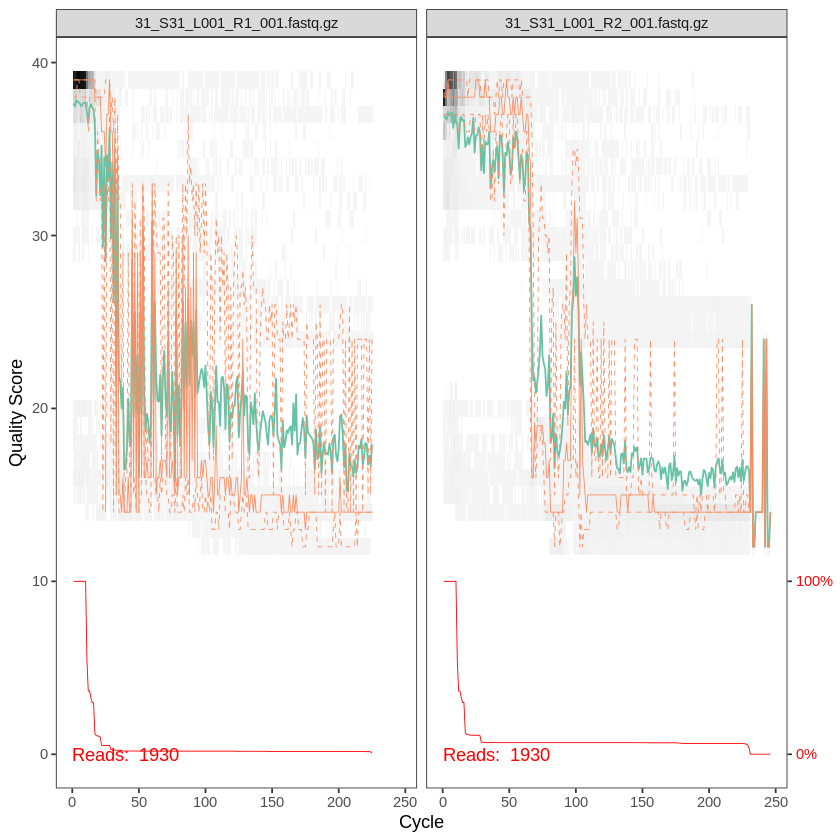

In [26]:
dada2::plotQualityProfile(file.path(cutadapt_dir, file_df_long$file[21:22]))

Notice that after filtering, the quality profiles are much better.

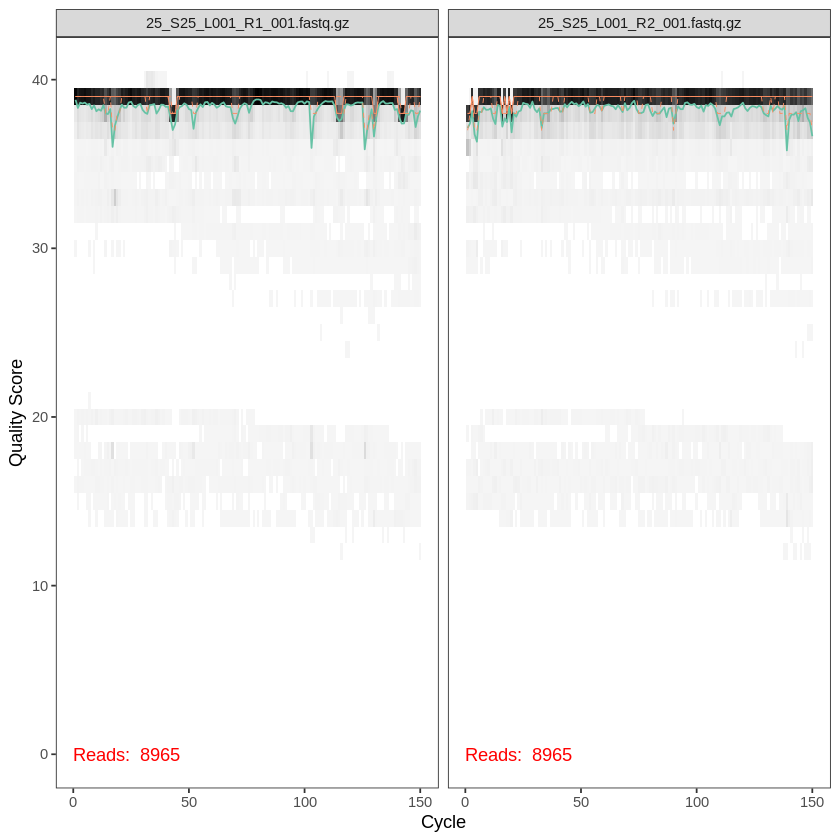

In [27]:
dada2::plotQualityProfile(file.path(filter_dir, file_df_long$file[9:10]))

Going forward let's select only the samples that have at least one read.

In [28]:
# Get the sample ID for the samples that have at least one read
clean_samples <- counts_filter |>
  dplyr::filter(records >= 1) |>
  merge(file_df_long, by.x = "row.names", by.y = "file") |>
  dplyr::select(sample_id) |>
  unique()

# Select the files for the samples that have at least one read
clean_forward_files <- file_df_wide |>
  dplyr::filter(sample_id %in% clean_samples$sample_id) |>
  dplyr::pull(forward)
clean_reverse_files <- file_df_wide |>
  dplyr::filter(sample_id %in% clean_samples$sample_id) |>
  dplyr::pull(reverse)

clean_samples

,sample_id
,<int>
1,21
3,22
5,23
7,24
9,25
11,26
13,27
15,28
17,29


## Amplicon Sequence Variants (ASVs) inference

Now we arrive at the core of the denoising process, called ASV inference.
The overall idea is that read errors can make one true sequence appear as multiple variants.
Maybe two sequences differ by a single base, which could be a sequencing error or could be a real difference.
Traditionally, denoising clusters similar sequences into groups called OTUs (operational taxonomic units) to reduce artificial variation.
`dada2` estimates error rates and uses them to infer which sequence variants are likely due to sequencing error.

### Learning the error rates

Let's start by learning the error rates for the forward and reverse reads.
This step fits a statistical model to the quality scores in our samples.

In [29]:
forward_errors <- dada2::learnErrors(
  file.path(filter_dir, clean_forward_files),
  multithread = TRUE
)

37769250 total bases in 251795 reads from 18 samples will be used for learning the error rates.


It is important to check that the model was fitted correctly, by checking the convergence of the model.
The last element should be close to 0, this indicates that the error model has successfully converged.

In [30]:
dada2:::checkConvergence(forward_errors)

[1] 4.225406e+01 2.038383e-01 1.808760e-02 1.568205e-04 0.000000e+00

And let's fit the reverse reads and check the convergence.

In [31]:
reverse_errors <- dada2::learnErrors(
  file.path(filter_dir, clean_reverse_files),
  multithread = TRUE
)

dada2:::checkConvergence(reverse_errors)

37769250 total bases in 251795 reads from 18 samples will be used for learning the error rates.


[1] 35.67445788  0.27760232  0.02499833  0.00000000

We can also check what the model learned.

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_line()`).”


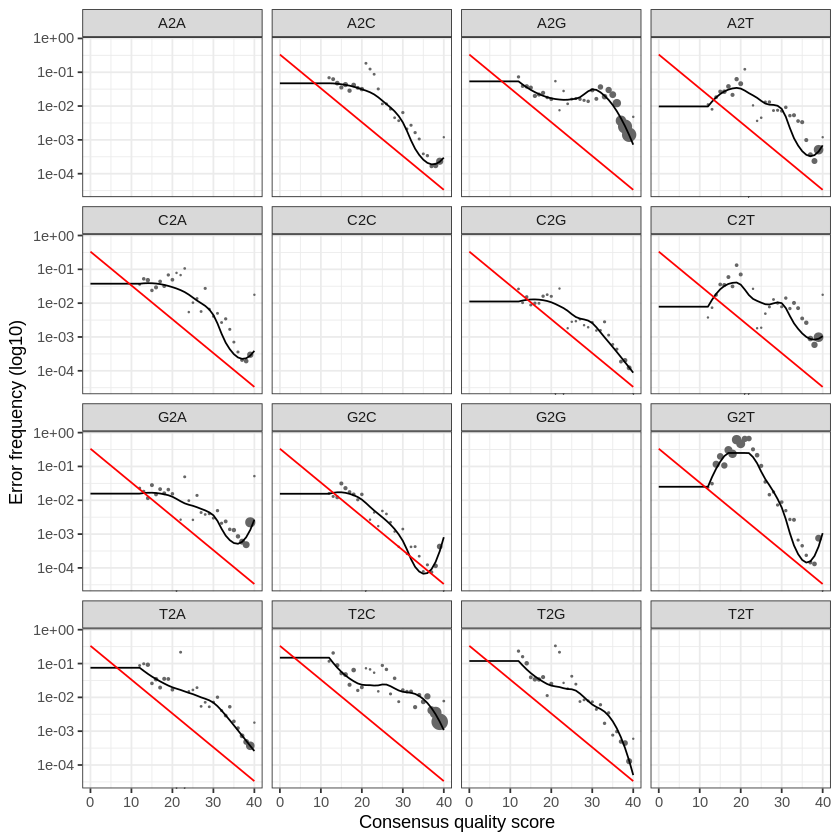

In [32]:
dada2::plotErrors(forward_errors, nominalQ = TRUE)

This plot shows both the observed (dots) and learned error rates (black curve) for each of the error scenarios (base X being misread as Y) as a function of the Phred score.
As long as the model (black curve) tracks the observed rates reasonably well, the error model is behaving as expected and we can continue.

And the reverse reads error rates.

In [ ]:
dada2::plotErrors(reverse_errors, nominalQ = TRUE)

Both look good.

### Cluster the sequences

With the error rates learned, we can now cluster the sequences by taking into account the error rates.

As a first step, let's dereplicate the sequences. Instead of running inference repeatedly for identical reads, we run it once per unique sequence with aggregated quality information.
We still keep track of how many times each sequence was repeated for downstream analysis.

In [33]:
forward_derep <- dada2::derepFastq(
  file.path(filter_dir, clean_forward_files),
  verbose = TRUE
)

Dereplicating sequence entries in Fastq file: data/filter/21_S21_L001_R1_001.fastq.gz

Encountered 4337 unique sequences from 31678 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/22_S22_L001_R1_001.fastq.gz

Encountered 2697 unique sequences from 24772 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/23_S23_L001_R1_001.fastq.gz

Encountered 470 unique sequences from 1843 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/24_S24_L001_R1_001.fastq.gz

Encountered 1457 unique sequences from 12505 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/25_S25_L001_R1_001.fastq.gz

Encountered 1631 unique sequences from 8965 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/26_S26_L001_R1_001.fastq.gz

Encountered 3347 unique sequences from 18881 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/27_S27_L001_R1_

In [34]:
reverse_derep <- dada2::derepFastq(
  file.path(filter_dir, clean_reverse_files),
  verbose = TRUE
)

Dereplicating sequence entries in Fastq file: data/filter/21_S21_L001_R2_001.fastq.gz

Encountered 4281 unique sequences from 31678 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/22_S22_L001_R2_001.fastq.gz

Encountered 2465 unique sequences from 24772 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/23_S23_L001_R2_001.fastq.gz

Encountered 415 unique sequences from 1843 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/24_S24_L001_R2_001.fastq.gz

Encountered 1366 unique sequences from 12505 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/25_S25_L001_R2_001.fastq.gz

Encountered 1507 unique sequences from 8965 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/26_S26_L001_R2_001.fastq.gz

Encountered 3126 unique sequences from 18881 total sequences read.

Dereplicating sequence entries in Fastq file: data/filter/27_S27_L001_R2_

And now we can run dada2 on the dereplicated files for both the forward and reverse reads.

In [35]:
forward_dada <- dada2::dada(
  forward_derep,
  err = forward_errors,
  multithread = TRUE,
  pool = "pseudo"
)

Sample 1 - 31678 reads in 4337 unique sequences.
Sample 2 - 24772 reads in 2697 unique sequences.
Sample 3 - 1843 reads in 470 unique sequences.
Sample 4 - 12505 reads in 1457 unique sequences.
Sample 5 - 8965 reads in 1631 unique sequences.
Sample 6 - 18881 reads in 3347 unique sequences.
Sample 7 - 127 reads in 56 unique sequences.
Sample 8 - 87 reads in 33 unique sequences.
Sample 9 - 6998 reads in 775 unique sequences.
Sample 10 - 771 reads in 259 unique sequences.
Sample 11 - 1570 reads in 384 unique sequences.
Sample 12 - 11575 reads in 2503 unique sequences.
Sample 13 - 3188 reads in 949 unique sequences.
Sample 14 - 24030 reads in 4245 unique sequences.
Sample 15 - 34322 reads in 4267 unique sequences.
Sample 16 - 5487 reads in 1228 unique sequences.
Sample 17 - 327 reads in 126 unique sequences.
Sample 18 - 64669 reads in 5729 unique sequences.

   selfConsist step 2

The process reports how many sequences were inferred. Now we repeat for the reverse reads.

In [36]:
reverse_dada <- dada2::dada(
  reverse_derep,
  err = reverse_errors,
  multithread = TRUE,
  pool = "pseudo"
)

Sample 1 - 31678 reads in 4281 unique sequences.
Sample 2 - 24772 reads in 2465 unique sequences.
Sample 3 - 1843 reads in 415 unique sequences.
Sample 4 - 12505 reads in 1366 unique sequences.
Sample 5 - 8965 reads in 1507 unique sequences.
Sample 6 - 18881 reads in 3126 unique sequences.
Sample 7 - 127 reads in 61 unique sequences.
Sample 8 - 87 reads in 34 unique sequences.
Sample 9 - 6998 reads in 846 unique sequences.
Sample 10 - 771 reads in 265 unique sequences.
Sample 11 - 1570 reads in 374 unique sequences.
Sample 12 - 11575 reads in 2197 unique sequences.
Sample 13 - 3188 reads in 894 unique sequences.
Sample 14 - 24030 reads in 4244 unique sequences.
Sample 15 - 34322 reads in 3690 unique sequences.
Sample 16 - 5487 reads in 1172 unique sequences.
Sample 17 - 327 reads in 113 unique sequences.
Sample 18 - 64669 reads in 5771 unique sequences.

   selfConsist step 2

### Merge the forward and reverse reads

Now that we have inferred ASVs, we can merge forward and reverse reads to build the final ASV table.
Here, read pairs are merged when they overlap by at least 12 bases.

In [37]:
merged <- dada2::mergePairs(
  forward_dada,
  forward_derep,
  reverse_dada,
  reverse_derep,
  minOverlap = 12,
  verbose = TRUE,
)

31418 paired-reads (in 91 unique pairings) successfully merged out of 31636 (in 131 pairings) input.

24614 paired-reads (in 74 unique pairings) successfully merged out of 24720 (in 111 pairings) input.

1833 paired-reads (in 16 unique pairings) successfully merged out of 1834 (in 17 pairings) input.

12454 paired-reads (in 56 unique pairings) successfully merged out of 12490 (in 72 pairings) input.

8902 paired-reads (in 37 unique pairings) successfully merged out of 8925 (in 50 pairings) input.

18633 paired-reads (in 54 unique pairings) successfully merged out of 18818 (in 73 pairings) input.

105 paired-reads (in 7 unique pairings) successfully merged out of 110 (in 8 pairings) input.

79 paired-reads (in 6 unique pairings) successfully merged out of 79 (in 6 pairings) input.

6933 paired-reads (in 5 unique pairings) successfully merged out of 6950 (in 8 pairings) input.

717 paired-reads (in 21 unique pairings) successfully merged out of 758 (in 23 pairings) input.

1546 paired-re

With the merged sequences we can now make a sequence table, which shows how many times each sequence was repeated for each sample.

In [38]:
seqtab <- dada2::makeSequenceTable(merged)

# Print the number of columns and rows
dim(seqtab)

[1]  18 294

The sequences have different lengths, depending on trimming and on how much forward and reverse reads overlap. Let's look at the length distribution.

In [39]:
table(nchar(dada2::getSequences(seqtab)))


150 151 152 153 154 155 157 158 159 160 161 163 166 176 183 184 193 200 202 204 
  1   1   4  19  27   2   2   1   1   1   1   1   2   1   1   2   1   1   2   1 
205 206 207 213 219 220 221 234 237 238 241 244 245 247 258 260 265 268 269 270 
 12   3   2   1   1  48   2   1   1   1   1   1  10   1   1   1   1   2  12   1 
271 272 273 274 278 
 55  47  11   2   4 

## Remove chimeras

One final step in this quality assurance process is to remove chimeras.
Chimeras are artificial sequences formed by joining parts of two or more true sequences.
They commonly arise during sequencing, but are relatively straightforward to detect and remove.
Here we use the `removeBimeraDenovo` function from the `dada2` package.

In [40]:
seqtab_nochim <- dada2::removeBimeraDenovo(
  seqtab,
  method = "consensus",
  multithread = TRUE,
  verbose = TRUE
)

# Print the number of columns and rows
dim(seqtab_nochim)

Identified 164 bimeras out of 294 input sequences.



[1]  18 130

We can now check what percentage of reads survived chimera removal.

In [41]:
sum(seqtab_nochim) / sum(seqtab)

[1] 0.9542549

And see the updated distribution of lengths.

In [42]:
table(nchar(dada2::getSequences(seqtab_nochim)))


150 151 152 153 154 155 157 158 159 160 161 163 166 176 183 184 193 200 202 204 
  1   1   4  10  10   2   2   1   1   1   1   1   2   1   1   2   1   1   2   1 
205 206 207 213 219 220 221 234 237 238 241 244 245 247 258 260 265 268 269 270 
  5   2   2   1   1  18   2   1   1   1   1   1   6   1   1   1   1   2   4   1 
271 272 273 274 278 
 14  10   4   1   2 

## Export data

After all these steps, we can be more confident that the resulting ASVs are meaningful and biologically relevant.

Let's export the ASVs to a file that contains the sequences, and another table with the number of times each ASV was found in each sample.
For this we use the `fasta` format, which is similar to `fastq` but does not include Phred scores; it stores only a sequence ID and the sequence.

Let's create a folder to store the resulting files.

In [43]:
asv_dir <- file.path(data_dir, "asv")

if (!dir.exists(asv_dir)) {
  dir.create(asv_dir, showWarnings = FALSE, recursive = TRUE)
}

And export the ASVs to a fasta file. We will name the sequences with "ASV_n" for the n-th ASV found.

In [44]:

asv_headers <- paste0("ASV_", seq_len(ncol(seqtab_nochim)))

dada2::uniquesToFasta(
  seqtab_nochim,
  fout = file.path(asv_dir, "clean_ASVs.fasta"),
  ids = asv_headers
)

And let's also save the counts of each ASV in a csv file:

In [45]:
write.table(
  t(seqtab_nochim),
  file.path(asv_dir, "clean_ASVs.csv"),
  sep = ",",
  quote = FALSE,
  col.names = NA,
  row.names = asv_headers
)

# Assign taxonomy

Once we have clean ASVs, the next step is to attempt to classify them into taxonomic groups and understand what we captured in our samples.

This step is similar in spirit to classification tasks you have seen with other data types (for example, assigning a species label to an image), but the algorithms are different.
For each query sequence, we search a large reference database, align the sequence to candidate matches, and quantify similarity (by percentage of shared base pairs).
So this is similar to the nearest-neighbour model covered before: labels come from the closest high-quality matches.

As in any machine learning workflow, performance depends strongly on the reference data.
Here, the "training data" is the database itself: if relevant taxa are missing, mislabeled, or unevenly represented, assignment quality drops.
This is especially important when working with underrepresented regions or taxa.

Assignment can also be difficult when there are multiple equally good matches with different taxonomic labels.
This could be a labelling error, or it could be that two groups share the same DNA sequence in that region.

## BLAST

The first step of the assignment process is the use of a powerful tool called `BLAST`.
BLAST is a sequence alignment tool.
It compares each query sequence to a reference database and returns the closest matches, along with alignment statistics such as percent identity, alignment length, and score.
BLAST performance depends strongly on the reference data.
Let's try two different databases for taxonomy assignment.

### Using the NCBI website

NCBI hosts large public sequence databases (including GenBank) that cover many organisms and studies.
This gives a broad first pass, but coverage and annotation quality can vary across groups and regions.

🖌️**NCBI Taxonomy Browser**

Go to the [Blast website](https://blast.ncbi.nlm.nih.gov/Blast.cgi?PROGRAM=blastn&PAGE_TYPE=BlastSearch&LINK_LOC=blasthome) and paste in the fasta results to run blast against the ASVs we found.
We will do this together and guided by Marina, please let us know when you arrive here so we can coordinate.

### Using custom database

Next, we will run taxonomy assignment with a custom reference database.
This database was assembled by Alejandro using records focused on the Mexico City region.
Compared with a very large public database, a curated local database can provide more representative examples of specimens similar to those in the sample.
At the same time, it may cover fewer taxa, and because we compare against fewer examples we may become overconfident (overfit) in some matches.


In [46]:
blast_dir <- file.path(data_dir, "blast")

if (!dir.exists(blast_dir)) {
  dir.create(blast_dir, showWarnings = FALSE, recursive = TRUE)
}

We start by creating a local BLAST database from the provided reference sequences.
This is just a technical step to prepare the database for BLAST.

In [47]:
reference_sequences <- file.path(
  metadata_dir,
  "Meta16S_MexicoCityCustomDatabase.fasta"
)

create_blast_db(
  fasta_path = reference_sequences,
  output_dir = file.path(blast_dir, "custom_database")
)

Now we run BLAST+ to match our ASVs against the custom database.

In [48]:
run_blastn(
  query_path = file.path(asv_dir, "clean_ASVs.fasta"),
  db_dir = file.path(blast_dir, "custom_database"),
  output_path = file.path(blast_dir, "blast_results.txt")
)

## BASTA

The blast results show which of the reference sequences are the closest matches to our ASVs.
But multiple matches can be found for the same sequence, and we need to decide which one to use.
This is where `BASTA` comes in.

BASTA is a tool for assigning a taxonomic label to a sequence, considering all the BLAST matches we have.
BASTA evaluates the set of high-quality hits (not just the top hit) and applies a Least Common Ancestor (LCA) strategy: when hits disagree, it assigns the deepest rank they consistently share.
In practice, this gives more robust labels and reduces overconfident species-level calls when the reference evidence is mixed.

Let's create a folder to store the output of BASTA.

In [49]:
basta_dir <- file.path(data_dir, "basta")

if (!dir.exists(basta_dir)) {
  dir.create(basta_dir, showWarnings = FALSE, recursive = TRUE)
}

And we also need to create a database for BASTA to use.

In [50]:
create_basta_db(
  file.path(metadata_dir, "mapping.tab"),
  "custom"
)

Finally we can run BASTA on the BLAST results.

In [51]:
run_basta(
  output_dir = file.path(basta_dir, "98_perc"),
  blast_path = file.path(blast_dir, "blast_results.txt"),
  database_name = "custom",
  identity = 98,
  alength = 200,
  percent = 80,
  minimum = 1
)

Notice the parameters. Here we are using 98% identity, meaning that we only consider matches where at least 98% of the query sequence matches the reference; all other hits are discarded.
We are also using an alignment length of 200 bp, which means that matches shorter than 200 bp are discarded.
We are also using `percent = 80`, which means that if 80% of surviving hits agree at a taxonomic level, we use that level; otherwise, we move to the next level.

All these parameters matter and are often a trade-off.
Demanding higher identity and higher alignment length will make sure only the best matches are used, but this means less sequences get assigned.
Lowering them will assign more sequences, but the taxonomic resolution will be lower due to more ambiguous matches.
Let's try with a lower identity.

In [61]:
run_basta(
  output_dir = file.path(basta_dir, "90_perc"),
  blast_path = file.path(blast_dir, "blast_results.txt"),
  database_name = "custom",
  identity = 90,
  alength = 200,
  percent = 80,
  minimum = 1
)

Next, we repeat the BASTA assignment against GenBank (`gb`) results to compare outcomes between a large global database and a smaller, curated regional database.
As you inspect outputs, focus on differences in certainty, taxonomic resolution, and robustness of assignments.
This comparison is a practical example of a common challenge in machine learning with underrepresented data: broader datasets provide scale, while curated local datasets may better represent the target context.

In [62]:
run_basta(
  output_dir = file.path(basta_dir, "90_perc_gb"),
  blast_path = file.path(data_dir, "blast_results.tab"),
  database_name = "gb",
  identity = 90,
  alength = 200,
  percent = 80,
  minimum = 1
)

In [63]:
run_basta(
  output_dir = file.path(basta_dir, "98_perc_gb"),
  blast_path = file.path(data_dir, "blast_results.tab"),
  database_name = "gb",
  identity = 98,
  alength = 200,
  percent = 80,
  minimum = 1
)

# Ecological Analysis

After all the work we've done so far, cleaning the reads and assigning them to taxa, we are finally ready to reconnect the analysis with Alejandro's original questions.

1) Did we detect the rare amphibians (*Ambystoma mexicanum* and *Lithobates tlaloci*)?
2) Do invasive species appear frequently, and how does their abundance compare with native species?
3) Do diversity patterns change with environmental covariates?

To do this we will use `phyloseq`, an R package originally designed for microbiome analysis, but that can also be used to analyse environmental DNA data.
To do this, we combine taxonomy assignments, ASV counts, and site metadata into one object.

In [64]:
site_df <- read.csv(file.path(metadata_dir, "LX_Site_Data.csv"))

site_df

SITENUMBER,TYPE,NAME,SITE_TYPE,LATITUDE,LONGITUDE,pH,Water_temperature.ºC.,EC.mS.,TDS.ppt.,Dissolved_oxygen.mg.L.,NITRATE,NITRITE,AMMONIA,PHOSPHATE,SULPHATE,SULPHUR,CHLORINE
<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,Wild site,Canal Japón I,Large Canal,19.28318,-99.07012,8.86,16.6,0.88,0.44,16.7,3.21,0.22,0.00,0.03,149,0.00,0.24
2,Wild site,Canal Japón II,Large Canal,19.28117,-99.07778,8.84,16.3,0.85,0.44,16.7,7.00,0.42,0.00,1.53,75,0.07,0.21
3,Wild site,Canal Paso del Águila,Large Canal,19.27378,-99.08597,8.40,17.7,0.87,0.45,20.0,8.80,0.68,0.00,1.76,110,0.03,0.47
4,Wild site,Laguna de Teshuilo,Lagoon,19.27101,-99.08768,8.65,18.3,0.95,0.44,20.0,12.60,0.57,0.00,1.67,96,0.04,0.14
5,Wild site,Canal de Teshuilo,Large Canal,19.26823,-99.08878,8.57,17.7,1.10,0.53,20.0,8.20,0.29,1.00,0.19,17,0.02,2.10
6,Wild site,Canal Apatlaco,Large Canal,19.26436,-99.08957,8.30,17.7,1.07,0.56,16.6,5.80,0.39,0.00,0.05,88,0.03,0.27
7,Wild site,Canal El Bordo I,Large Canal,19.28341,-99.08023,8.31,18.5,0.95,0.49,20.0,8.50,0.09,0.34,0.03,133,0.01,0.28
8,Refuge,Felipe Barerra’s refuge,Refuge,19.27319,-99.09401,9.22,18.5,1.11,0.55,15.4,1.25,0.00,0.00,0.63,113,0.00,0.07
9,Refuge,Olintalli refuge,Refuge,19.27821,-99.09422,8.00,16.2,1.04,0.53,4.5,0.12,0.09,0.81,22.40,92,0.05,0.33


For the ecological questions below, we use the custom-database assignment at 98% identity (`final_taxonomy.txt`) because it is the most conservative option.

In [70]:
taxa <- read_taxa_from_basta(file.path(basta_dir, "98_perc", "custom-98-200-80-1", "final_taxonomy.txt"))

taxa

Warning message in file(file, "rt"):
“cannot open file 'data/basta/98_perc/custom-98-200-80-1/final_taxonomy.txt': No such file or directory”


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'as.matrix': cannot open the connection


Now we read the ASV count table and keep only ASVs with taxonomy assignments.

In [ ]:
# Read the OTU table but only keep the ASVs for which we have taxonomy
otu <- read.table(
  file.path(asv_dir, "clean_ASVs.csv"),
  sep = ",",
  row.names = 1,
  header = TRUE
)

# Rename the columns to match the sample IDs
colnames(otu) <- stringr::str_extract(colnames(otu), "S\\d+")

# Convert the OTU table to a matrix
otu <- as.matrix(otu[row.names(taxa), ])

otu

Next we link sequence samples to site metadata.

In [ ]:
sample_ids <- colnames(otu)
sample_data <- tibble::tibble(
  SampleID = sample_ids,
  SITENUMBER = as.integer(stringr::str_remove(sample_ids, "^S"))
) |>
  dplyr::left_join(site_df, by = "SITENUMBER") |>
  tibble::column_to_rownames("SampleID")

# Keep only samples that have metadata
keep_samples <- row.names(sample_data)[!is.na(sample_data$SITENUMBER)]
sample_data <- sample_data[keep_samples, , drop = FALSE]
otu <- otu[, keep_samples, drop = FALSE]

sample_data

Now we can create the `phyloseq` object.

In [ ]:
ps <- phyloseq::phyloseq(
  phyloseq::tax_table(taxa),
  phyloseq::otu_table(otu, taxa_are_rows = TRUE),
  phyloseq::sample_data(sample_data)
)

ps

This creates an object containing taxonomy, abundance, and metadata together, which we can use to explore the data.

## 1) Rare amphibians

First, we check whether the two focal amphibians appear in the dataset, and where they were detected.
If this table is empty, we did not detect those species in this subset under the current taxonomy settings.

In [ ]:
rare_species <- c("Ambystoma mexicanum", "Lithobates tlaloci")

# Did we detect the species?
as.data.frame(taxa) |>
  dplyr::filter(Species %in% rare_species)

What if we look at the genus level?

In [ ]:
rare_species_genus <- c("Ambystoma", "Lithobates")

# Did we detect the genus?
as.data.frame(taxa) |>
  dplyr::filter(Genus %in% rare_species_genus)

Unfortunately, no rare amphibians were found in this subset of the data.
In the larger dataset, axolotls were only found in dedicated refugia maintained by local communities.
This likely reflects that this species has been negatively affected and may be unviable in much of the current environment.

## 2) Invasive vs native species

Now let's look at the overall abundance of the taxa we found.
This can help us compare the relative abundance of invasive and native taxa.

First, here are absolute abundances by sample.

In [ ]:
phyloseq::plot_bar(ps, fill = "Family")

Now we convert to relative abundance per sample, which makes comparisons across samples easier.

In [ ]:
ps_status_rel <- phyloseq::transform_sample_counts(ps, function(x) {
  x / sum(x)
})

phyloseq::plot_bar(ps_status_rel, fill = "Family")

These plots let us quickly compare composition patterns across samples.
However, keep in mind that read abundance is not a direct count of individuals.

## 3) Environmental covariates and diversity

Finally, we test whether diversity changes with environmental conditions.
As a first pass, we use Shannon diversity and compare it against nitrate.

In [ ]:
phyloseq::plot_richness(
  ps,
  measures = c("Observed", "Shannon"),
  x = "NITRATE"
)

You can repeat this same plot with other covariates to see whether the same trend appears.

This is just exploratory.
Here is where you would use a formal statistical model to answer these questions.